# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [85]:
import numpy as np
import pandas as pd
import sklearn as sk
from jedi.inference.utils import to_list
import seaborn as sns
import matplotlib.pyplot as plt

---
## 2. Load data

In [ ]:
df = pd.read_csv('../data/clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              14606 non-null  object        
 1   channel_sales                   14606 non-null  object        
 2   cons_12m                        14606 non-null  int64         
 3   cons_gas_12m                    14606 non-null  int64         
 4   cons_last_month                 14606 non-null  int64         
 5   date_activ                      14606 non-null  datetime64[ns]
 6   date_end                        14606 non-null  datetime64[ns]
 7   date_modif_prod                 14606 non-null  datetime64[ns]
 8   date_renewal                    14606 non-null  datetime64[ns]
 9   forecast_cons_12m               14606 non-null  float64       
 10  forecast_cons_year              14606 non-null  int64         
 11  fo

In [88]:
df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


---

## 3. Feature engineering

### Difference between off-peak prices in December and preceding January

Below is the code created by your colleague to calculate the feature described above. Use this code to re-create this feature and then think about ways to build on this feature to create features with a higher predictive power.

In [ ]:
price_df = pd.read_csv('../data/price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')
price_df.head()

In [90]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


Now it is time to get creative and to conduct some of your own feature engineering! Have fun with it, explore different ideas and try to create as many as you can!

one-hot encoding
- convert the "channel_sales" and "origin_up" into understandable features for machine learning

In [91]:
CONVERTED_DATA = ["channel_sales", "origin_up"]
MIN_NUMBER = 50
for col in CONVERTED_DATA:
    display(col)
    reserved_col = df[col].value_counts()
    display(reserved_col)
    reserved_col = reserved_col[reserved_col > MIN_NUMBER].index
    display(reserved_col)
    df = pd.get_dummies(df, columns = [col],  dtype = int)
df.head()

'channel_sales'

channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

Index(['foosdfpfkusacimwkcsosbicdxkicaua', 'MISSING',
       'lmkebamcaaclubfxadlmueccxoimlema', 'usilxuppasemubllopkaafesmlibmsdf',
       'ewpakwlliwisiwduibdlfmalxowmwpci'],
      dtype='object', name='channel_sales')

'origin_up'

origin_up
lxidpiddsbxsbosboudacockeimpuepw    7097
kamkkxfxxuwbdslkwifmmcsiusiuosws    4294
ldkssxwpmemidmecebumciepifcamkci    3148
MISSING                               64
usapbepcfoloekilkwsdiboslwaxobdp       2
ewxeelcelemmiwuafmddpobolfuxioce       1
Name: count, dtype: int64

Index(['lxidpiddsbxsbosboudacockeimpuepw', 'kamkkxfxxuwbdslkwifmmcsiusiuosws',
       'ldkssxwpmemidmecebumciepifcamkci', 'MISSING'],
      dtype='object', name='origin_up')

,id,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,...,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_MISSING,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp
0,24011ae4ebbe3035111d65fa7c15bc57,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,...,1,0,0,0,0,0,0,0,1,0
1,d29c2c54acc38ff3c0614d0a653813dd,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,...,0,0,0,0,0,0,1,0,0,0
2,764c75f661154dac3a6c254cd082ea7d,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,...,1,0,0,0,0,0,1,0,0,0
3,bba03439a292a1e166f80264c16191cb,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,...,0,1,0,0,0,0,1,0,0,0
4,149d57cf92fc41cf94415803a877cb4b,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,...,0,0,0,0,0,0,1,0,0,0


In [92]:
monthly_price_by_id.info()
display(monthly_price_by_id)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  193002 non-null  object        
 1   price_date          193002 non-null  datetime64[ns]
 2   price_off_peak_var  193002 non-null  float64       
 3   price_off_peak_fix  193002 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 5.9+ MB


,id,price_date,price_off_peak_var,price_off_peak_fix
0,0002203ffbb812588b632b9e628cc38d,2015-01-01,0.126098,40.565969
1,0002203ffbb812588b632b9e628cc38d,2015-02-01,0.126098,40.565969
2,0002203ffbb812588b632b9e628cc38d,2015-03-01,0.128067,40.728885
3,0002203ffbb812588b632b9e628cc38d,2015-04-01,0.128067,40.728885
4,0002203ffbb812588b632b9e628cc38d,2015-05-01,0.128067,40.728885
...,...,...,...,...
192997,ffff7fa066f1fb305ae285bb03bf325a,2015-08-01,0.119916,40.728885
192998,ffff7fa066f1fb305ae285bb03bf325a,2015-09-01,0.119916,40.728885
192999,ffff7fa066f1fb305ae285bb03bf325a,2015-10-01,0.119916,40.728885
193000,ffff7fa066f1fb305ae285bb03bf325a,2015-11-01,0.119916,40.728885


In [93]:
PRICE_COLUMNS = price_df.columns[2:]
display(PRICE_COLUMNS)

Index(['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
       'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix'],
      dtype='object')

In [94]:
price_df = price_df.sort_values(['id', 'price_date'])
change_cnt = pd.DataFrame()

for col in PRICE_COLUMNS:
    display(col)
    cur_price = price_df[['id', col]]
    prev_price = cur_price.shift(1)
    price_changed = pd.DataFrame({
        'id': cur_price['id'],
        'has_changed': (cur_price[col] != prev_price[col]) & (cur_price['id'] == prev_price['id']) & (prev_price[col].notna())
    })
    change_cnt[col] = price_changed.groupby('id').sum()
#
# display(change_cnt.head(20))
# display(change_cnt.info)
# change_cnt = change_cnt.reset_index()
# display(change_cnt)




'price_off_peak_var'

'price_peak_var'

'price_mid_peak_var'

'price_off_peak_fix'

'price_peak_fix'

'price_mid_peak_fix'

In [95]:
price_df = price_df.sort_values(['id', 'price_date'])
prev_prices = price_df.groupby('id')[PRICE_COLUMNS].shift(1)
is_changed = price_df[PRICE_COLUMNS].ne(prev_prices) & prev_prices.notna()
    # ne a function that executes != line by line
change_cnt = is_changed.groupby(price_df['id']).sum()
change_cnt.rename(columns = {'price_off_peak_var': 'price_off_peak_var_chg',
                               'price_peak_var': 'price_peak_var_chg',
                               'price_mid_peak_var'	: 'price_mid_peak_var_chg',
                               'price_off_peak_fix'	: 'price_off_peak_fix_chg',
                               'price_peak_fix'	: 'price_peak_fix_chg',
                               'price_mid_peak_fix': 'price_mid_peak_fix_chg'}, inplace = True)
display(change_cnt.head())

,price_off_peak_var_chg,price_peak_var_chg,price_mid_peak_var_chg,price_off_peak_fix_chg,price_peak_fix_chg,price_mid_peak_fix_chg
id,,,,,,
0002203ffbb812588b632b9e628cc38d,2,2,2,1,1,1
0004351ebdd665e6ee664792efc4fd13,2,0,0,1,0,0
0010bcc39e42b3c2131ed2ce55246e3c,3,0,0,1,0,0
0010ee3855fdea87602a5b7aba8e42de,2,2,2,2,2,2
00114d74e963e47177db89bc70108537,2,0,0,1,0,0


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 56 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   id                                              14606 non-null  object        
 1   cons_12m                                        14606 non-null  int64         
 2   cons_gas_12m                                    14606 non-null  int64         
 3   cons_last_month                                 14606 non-null  int64         
 4   date_activ                                      14606 non-null  datetime64[ns]
 5   date_end                                        14606 non-null  datetime64[ns]
 6   date_modif_prod                                 14606 non-null  datetime64[ns]
 7   date_renewal                                    14606 non-null  datetime64[ns]
 8   forecast_cons_12m                             

In [97]:
has_gas_map = {'t': 1, 'f': 0}
df['has_gas'] = df['has_gas'].map(has_gas_map)

In [98]:
CURRENT_DATE = pd.to_datetime('2016-01-01', yearfirst= True, format = '%Y-%m-%d')
CURRENT_DATE

Timestamp('2016-01-01 00:00:00')

In [99]:
DATE_COLUMNS = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
df['tenure'] = round((df['date_end'] - df['date_activ'])/pd.Timedelta(days = 365),1)
for col in DATE_COLUMNS:
    df[col] = abs(round((CURRENT_DATE - df[col])/pd.Timedelta(days = 30),1))
df.rename(columns={'date_activ': 'month_activ', 'date_end': 'month_to_end', 'date_modif_prod': 'month_modif_prod',
    'date_renewal': 'month_renew'}, inplace=True)

In [100]:
display(df)
df.info()

,id,cons_12m,cons_gas_12m,cons_last_month,month_activ,month_to_end,month_modif_prod,month_renew,forecast_cons_12m,forecast_cons_year,...,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_MISSING,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp,tenure
0,24011ae4ebbe3035111d65fa7c15bc57,0,54946,0,31.0,5.5,2.0,6.4,0.00,0,...,0,0,0,0,0,0,0,1,0,3.0
1,d29c2c54acc38ff3c0614d0a653813dd,4660,0,0,77.5,8.1,77.5,4.1,189.95,0,...,0,0,0,0,0,1,0,0,0,7.0
2,764c75f661154dac3a6c254cd082ea7d,544,0,0,69.5,3.5,69.5,8.6,47.96,0,...,0,0,0,0,0,1,0,0,0,6.0
3,bba03439a292a1e166f80264c16191cb,1584,0,0,70.1,3.0,70.1,9.2,240.04,0,...,1,0,0,0,0,1,0,0,0,6.0
4,149d57cf92fc41cf94415803a877cb4b,4425,0,526,72.6,2.2,72.6,9.9,445.75,526,...,0,0,0,0,0,1,0,0,0,6.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,32270,47940,0,43.9,4.3,7.9,19.5,4648.01,0,...,0,0,0,0,0,0,0,1,0,4.0
14602,d0a6f71671571ed83b2645d23af6de00,7223,0,181,40.7,8.0,40.7,4.2,631.69,181,...,0,0,0,0,0,0,0,1,0,4.0
14603,10e6828ddd62cbcf687cb74928c4c2d2,1844,0,179,47.4,1.2,47.4,10.9,190.39,179,...,0,0,0,0,0,0,0,1,0,4.0
14604,1cf20fd6206d7678d5bcafd28c53b4db,131,0,0,40.6,8.1,40.6,4.1,19.34,0,...,0,0,0,0,0,0,0,1,0,4.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 57 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              14606 non-null  object 
 1   cons_12m                                        14606 non-null  int64  
 2   cons_gas_12m                                    14606 non-null  int64  
 3   cons_last_month                                 14606 non-null  int64  
 4   month_activ                                     14606 non-null  float64
 5   month_to_end                                    14606 non-null  float64
 6   month_modif_prod                                14606 non-null  float64
 7   month_renew                                     14606 non-null  float64
 8   forecast_cons_12m                               14606 non-null  float64
 9   forecast_cons_year                     

In [101]:
FORECAST = df.columns[np.r_[1,2,8:15]]
FORECAST

Index(['cons_12m', 'cons_gas_12m', 'forecast_cons_12m', 'forecast_cons_year',
       'forecast_discount_energy', 'forecast_meter_rent_12m',
       'forecast_price_energy_off_peak', 'forecast_price_energy_peak',
       'forecast_price_pow_off_peak'],
      dtype='object')

In [102]:
df[FORECAST] = np.log10(df[FORECAST]+1)
df

,id,cons_12m,cons_gas_12m,cons_last_month,month_activ,month_to_end,month_modif_prod,month_renew,forecast_cons_12m,forecast_cons_year,...,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_MISSING,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp,tenure
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0,31.0,5.5,2.0,6.4,0.000000,0.000000,...,0,0,0,0,0,0,0,1,0,3.0
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0,77.5,8.1,77.5,4.1,2.280920,0.000000,...,0,0,0,0,0,1,0,0,0,7.0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0,69.5,3.5,69.5,8.6,1.689841,0.000000,...,0,0,0,0,0,1,0,0,0,6.0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0,70.1,3.0,70.1,9.2,2.382089,0.000000,...,1,0,0,0,0,1,0,0,0,6.0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,526,72.6,2.2,72.6,9.9,2.650065,2.721811,...,0,0,0,0,0,1,0,0,0,6.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14601,18463073fb097fc0ac5d3e040f356987,4.508812,4.680707,0,43.9,4.3,7.9,19.5,3.667360,0.000000,...,0,0,0,0,0,0,0,1,0,4.0
14602,d0a6f71671571ed83b2645d23af6de00,3.858778,0.000000,181,40.7,8.0,40.7,4.2,2.801191,2.260071,...,0,0,0,0,0,0,0,1,0,4.0
14603,10e6828ddd62cbcf687cb74928c4c2d2,3.265996,0.000000,179,47.4,1.2,47.4,10.9,2.281919,2.255273,...,0,0,0,0,0,0,0,1,0,4.0
14604,1cf20fd6206d7678d5bcafd28c53b4db,2.120574,0.000000,0,40.6,8.1,40.6,4.1,1.308351,0.000000,...,0,0,0,0,0,0,0,1,0,4.0


['cons_12m',
 'cons_gas_12m',
 'forecast_cons_12m',
 'forecast_cons_year',
 'forecast_discount_energy',
 'forecast_meter_rent_12m',
 'forecast_price_energy_off_peak',
 'forecast_price_energy_peak',
 'forecast_price_pow_off_peak']

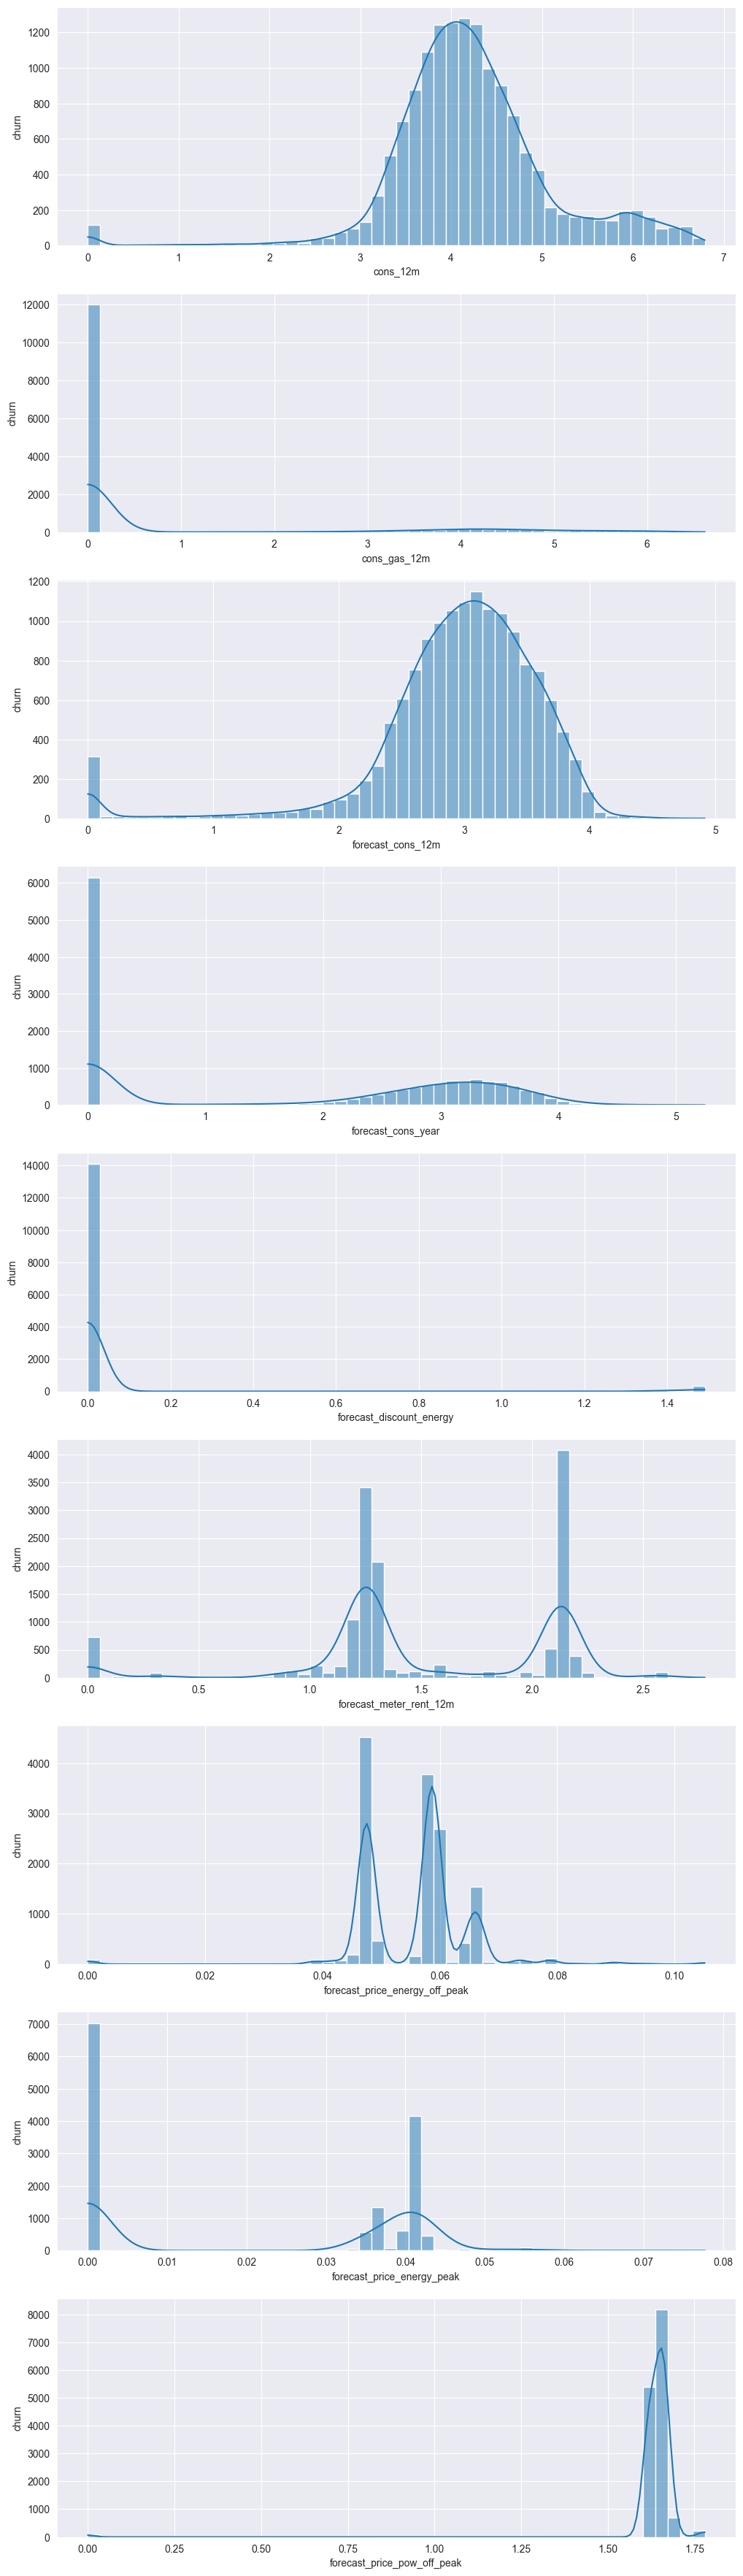

In [103]:
def plot_hist(dataframe, column, ax):
    sns.histplot(x=dataframe[column].dropna(), ax=ax, kde=True, bins= 50)
    ax.set_xlabel(column)
    ax.set_ylabel('churn')


data_to_be_checked = df.columns[np.r_[1,2,8:15]].tolist()
display(data_to_be_checked)
fig, axs = plt.subplots(nrows=len(data_to_be_checked), figsize=(12, 5 * len(data_to_be_checked)))
plt.ticklabel_format(style='plain', axis='x')

for column, ax in zip(data_to_be_checked, axs):
    plot_hist(df, column, ax)

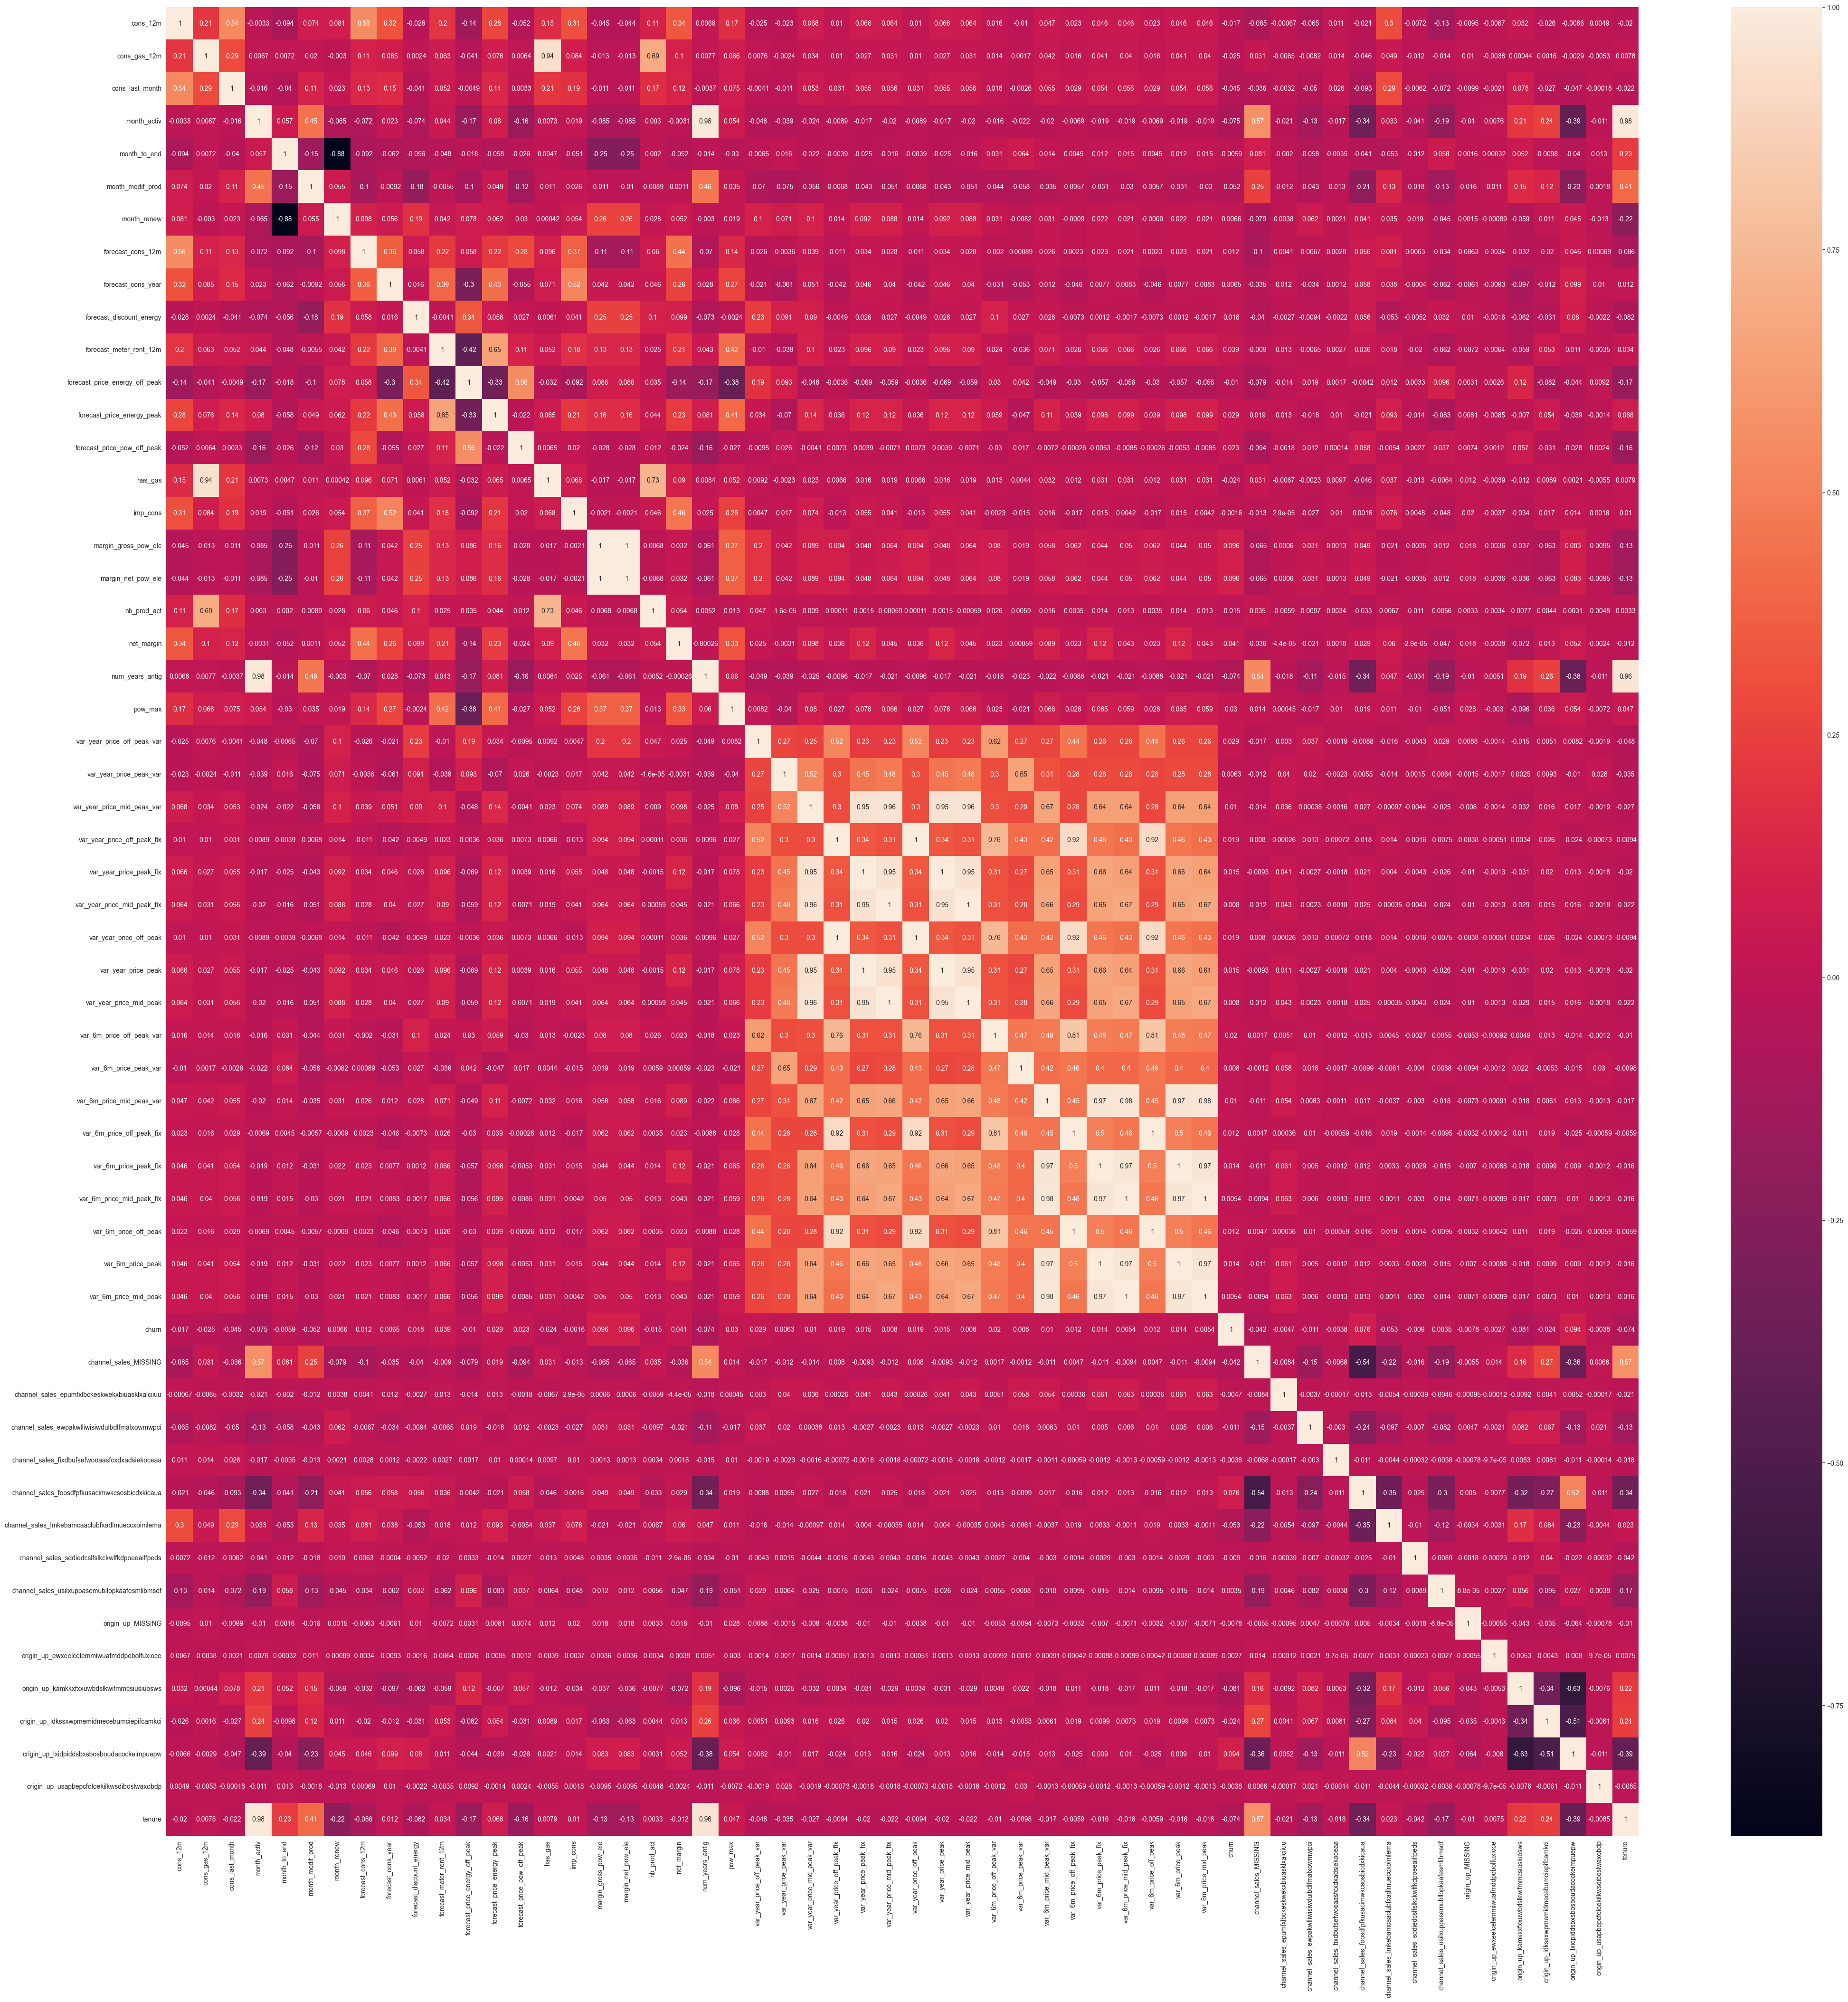

In [104]:
correlation = df.drop(columns = ['id']).corr()


plt.figure(figsize = (50, 50))
sns.heatmap(correlation, annot=True, xticklabels= correlation.index, yticklabels=correlation.columns)

plt.show()

In [105]:
DROP_COLUMNS = []
for (i, index) in enumerate(correlation.index[0:-1]):
    for (j,col) in enumerate(correlation.columns[i+1:]):
        if (correlation[index][col]>0.9) & (col not in DROP_COLUMNS):
            DROP_COLUMNS.append(col)
DROP_COLUMNS

['has_gas',
 'num_years_antig',
 'tenure',
 'margin_net_pow_ele',
 'var_year_price_peak_fix',
 'var_year_price_mid_peak_fix',
 'var_year_price_peak',
 'var_year_price_mid_peak',
 'var_year_price_off_peak',
 'var_6m_price_off_peak_fix',
 'var_6m_price_off_peak',
 'var_6m_price_peak_fix',
 'var_6m_price_mid_peak_fix',
 'var_6m_price_peak',
 'var_6m_price_mid_peak']

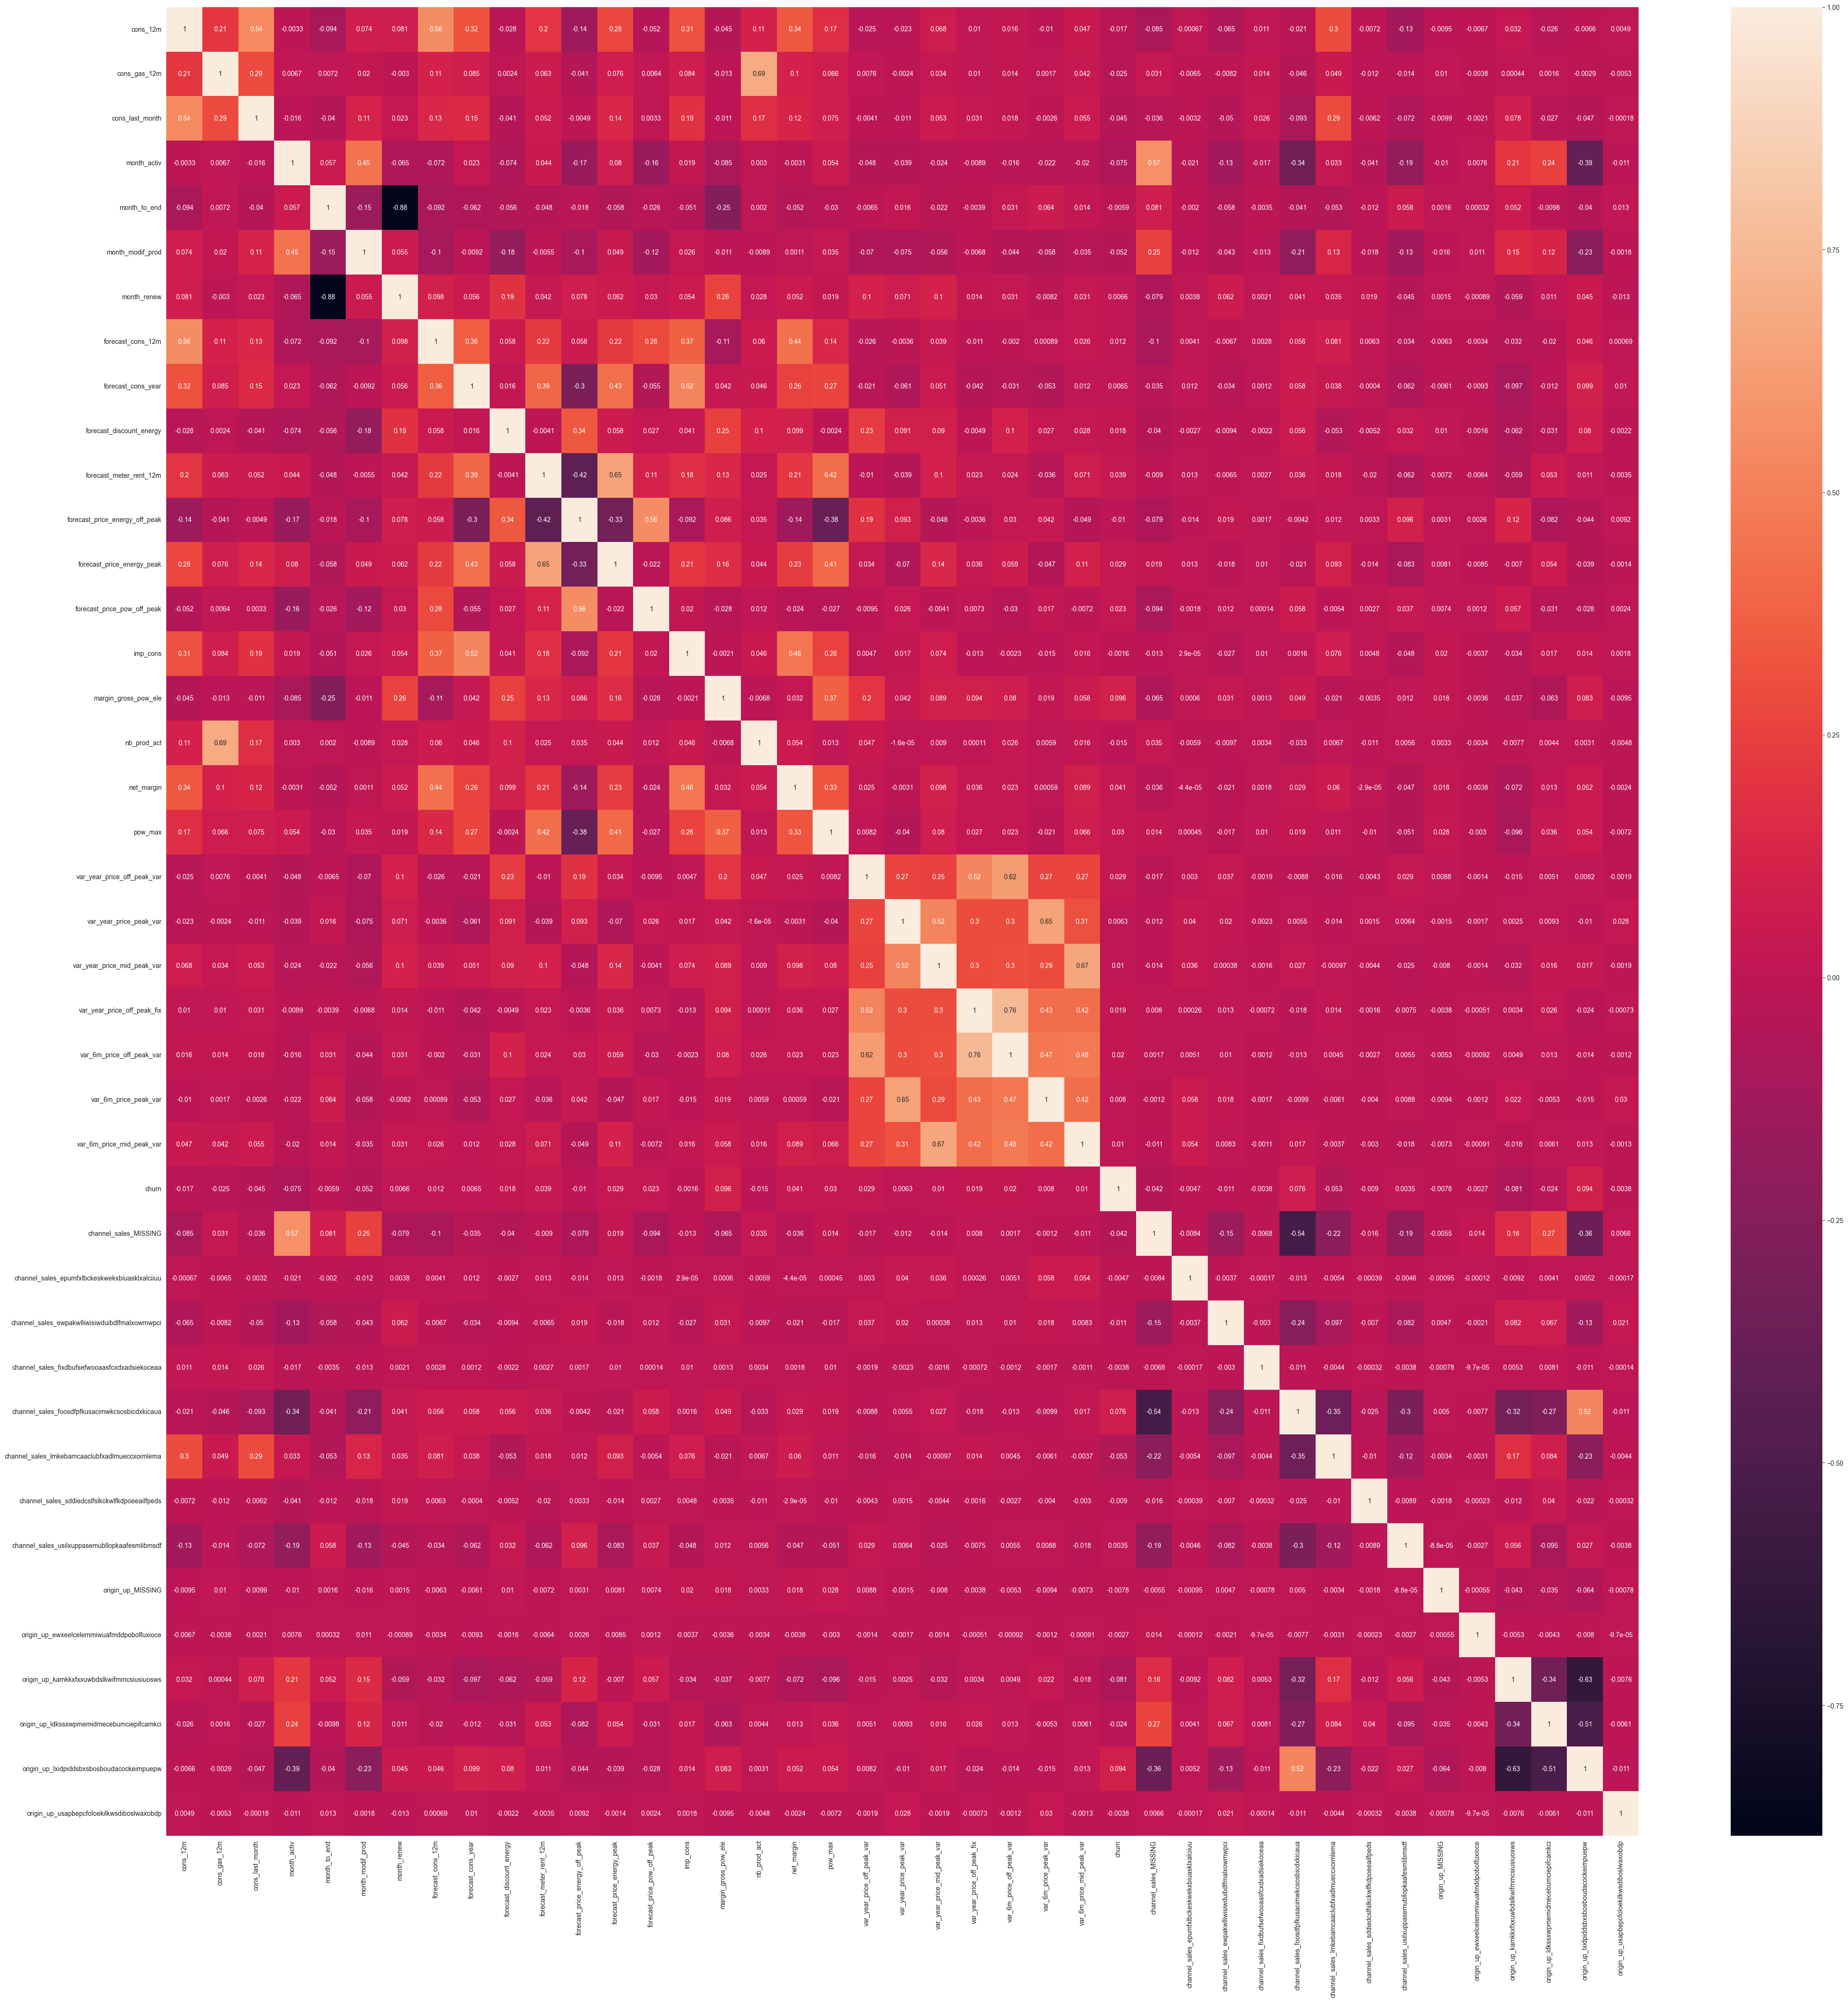

In [106]:
adjusted_correlation = df.drop(columns = ['id']+DROP_COLUMNS).corr()


plt.figure(figsize = (50, 50))
sns.heatmap(adjusted_correlation, annot=True, xticklabels = adjusted_correlation.index, yticklabels = adjusted_correlation.columns)

plt.show()

In [ ]:
data_for_prediction = df.drop(columns = DROP_COLUMNS)
display(data_for_prediction)

data_for_prediction = data_for_prediction.merge(diff, on = 'id')
data_for_prediction = data_for_prediction.merge(change_cnt, on = 'id')


display(data_for_prediction)

data_for_prediction.to_csv('../data/my_data_for_prediction.csv')

In [108]:
data_for_prediction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 50 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              14606 non-null  object 
 1   cons_12m                                        14606 non-null  float64
 2   cons_gas_12m                                    14606 non-null  float64
 3   cons_last_month                                 14606 non-null  int64  
 4   month_activ                                     14606 non-null  float64
 5   month_to_end                                    14606 non-null  float64
 6   month_modif_prod                                14606 non-null  float64
 7   month_renew                                     14606 non-null  float64
 8   forecast_cons_12m                               14606 non-null  float64
 9   forecast_cons_year                     